Neste notebook faremos uma rede neural para classificar imagens de digitos manuscritos de 0 a 9:

In [1]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

2026-02-09 18:04:33.739295: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-09 18:04:33.755720: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770671073.777314   52173 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770671073.783663   52173 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-09 18:04:33.801100: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Cada entrada no dataset possuí a imagem (já codificada em um array) de digitos de 0 a 9:

In [2]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [3]:
y_train[0]

np.uint8(5)

Esse registro representa o número 5:

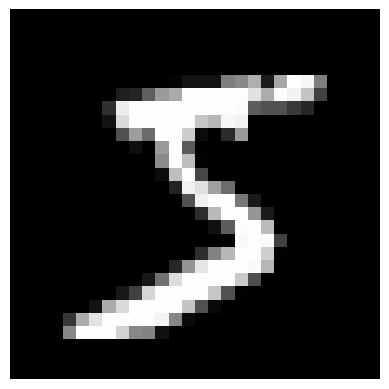

In [4]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="gray")
plt.axis("off")
plt.show()

Temos 60000 digitos manuscritos com 784 pixels cada um (28 x 28):

In [5]:
X_train.shape

(60000, 28, 28)

Normaliza-se os valores dos pixels das imagens, para que eles possuam apenas valores entre 0 e 1.

In [6]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [7]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

Faz-se OneHotEncoding em y:

In [8]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(sparse_output=False)

y_train_encoded = onehot.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = onehot.transform(y_test.reshape(-1, 1))

#Representa o código do digito 5
y_train_encoded[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

Separaremos o dataset de treino em 468 batches de 128 imagens cada:

In [9]:
batch_size = 128

num_batches = int(len(X_train) / batch_size)

num_batches

468

In [10]:
X_batches = np.array_split(X_train, num_batches)
y_batches = np.array_split(y_train_encoded, num_batches)

In [11]:
y_batches

[array([[0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([[0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 1., 0.]]),
 array([[0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.]]),
 arr

Definiremos a rede neural, que terá 728 neuronios na camada de entrada (Um para cada pixel / feature dos registros)

In [12]:
neuronios_entrada = X_train.shape[1] * X_train.shape[2]

neuronios_entrada

784

Tera 10 neuronios na camada de saída, um neuronio para representar a probabilidade de cada digito de 0 a 9:

In [13]:
neuronios_saida = y_train_encoded.shape[1]

neuronios_saida

10

Serão definidas 3 camadas ocultas (Não sei exatamente por que 3)

Cada camada oculta tera o numero de neuronios igual a soma do numero de neuronios de entrada e saida dividido por 2, arredondando para cima:

In [14]:
neuronios_oculta1 = int(np.ceil((neuronios_entrada + neuronios_saida)/2))
neuronios_oculta2 = neuronios_oculta1
neuronios_oculta3 = neuronios_oculta2

print(neuronios_oculta1)
print(neuronios_oculta2)
print(neuronios_oculta3)

397
397
397


In [15]:
import tensorflow as tf

Define-se os pesos e biases de cada camada:

In [16]:
W = {"oculta1": tf.Variable(tf.random.normal([neuronios_entrada, neuronios_oculta1])),
     "oculta2": tf.Variable(tf.random.normal([neuronios_oculta1, neuronios_oculta2])),
     "oculta3": tf.Variable(tf.random.normal([neuronios_oculta2, neuronios_oculta3])),
     "saida": tf.Variable(tf.random.normal([neuronios_oculta3, neuronios_saida]))}

W

2026-02-09 18:04:38.777876: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1770671078.777935   52173 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


{'oculta1': <tf.Variable 'Variable:0' shape=(784, 397) dtype=float32, numpy=
 array([[-0.28222898,  0.58874166, -0.46515897, ..., -0.51334167,
          0.9437381 , -1.6946417 ],
        [ 1.6543363 , -0.2592137 , -2.340879  , ...,  0.7836992 ,
          0.14936656,  0.7493938 ],
        [ 0.1298112 , -0.3006587 ,  0.75387627, ...,  0.5782327 ,
         -0.80471295, -1.0980763 ],
        ...,
        [ 1.3811522 , -0.31742764, -0.8241448 , ..., -1.6619538 ,
         -0.06858874,  0.44493207],
        [ 0.99489266, -0.57169753,  0.4657368 , ...,  0.585508  ,
          0.49465063,  0.29998246],
        [-0.4626109 , -0.975071  , -0.9559523 , ..., -0.17839862,
         -1.338251  , -1.0305544 ]], dtype=float32)>,
 'oculta2': <tf.Variable 'Variable:0' shape=(397, 397) dtype=float32, numpy=
 array([[-0.5115757 ,  0.28551367,  0.64549315, ...,  0.5797325 ,
         -0.5786123 , -0.2754436 ],
        [-1.294832  ,  0.13338344, -0.43898425, ..., -0.2671203 ,
         -1.3463075 , -0.6159286 ],

In [17]:
b = {"oculta1": tf.Variable(tf.random.normal([neuronios_oculta1])),
     "oculta2": tf.Variable(tf.random.normal([neuronios_oculta2])),
     "oculta3": tf.Variable(tf.random.normal([neuronios_oculta3])),
     "saida": tf.Variable(tf.random.normal([neuronios_saida]))}

b

{'oculta1': <tf.Variable 'Variable:0' shape=(397,) dtype=float32, numpy=
 array([ 0.48972353, -0.37799084,  0.25566107,  0.6550031 , -1.1877846 ,
        -0.23305081,  0.80395174, -0.81405413, -0.1841918 ,  0.3727775 ,
         1.5615748 , -1.1021874 ,  1.5632341 , -0.9245201 ,  0.35744047,
         1.7632664 ,  0.6466554 , -0.3498456 , -0.32682493, -0.23139913,
        -0.22445075, -0.3020425 , -0.9391542 ,  0.54545057,  1.5600317 ,
        -1.5441719 , -1.6913246 ,  0.28943264, -1.6407622 ,  1.2924359 ,
         2.0551221 ,  1.3224596 ,  1.3572949 ,  0.3053867 ,  1.3874654 ,
        -0.23373143,  1.9284452 ,  1.3027325 ,  0.75065815,  0.08538086,
         1.3800287 , -1.3679141 ,  1.0993121 ,  0.8602777 ,  0.559963  ,
         0.2249473 ,  0.17715576, -0.19662492, -0.75625795, -1.0644265 ,
         0.4966256 ,  1.6706407 , -0.52200556, -0.8937175 , -1.8386475 ,
        -0.69163406, -0.41362464,  0.502708  , -1.471332  ,  0.33553424,
         1.4588598 , -0.65071857, -1.2789614 ,  0.9

Converte-se o dataset para tensores

In [18]:
X_train = tf.convert_to_tensor(X_train, dtype = tf.float32, name = 'X')
y_train = tf.convert_to_tensor(y_train, dtype = tf.float32, name = 'y')
X_test = tf.convert_to_tensor(X_test, dtype = tf.float32, name = 'X')
y_test = tf.convert_to_tensor(y_test, dtype = tf.float32, name = 'y')

print(X_train)
print(y_train)
print(X_test)
print(y_test)

tf.Tensor(
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]

Define-se o modelo da rede neural:

In [19]:
@tf.function
def mlp(X, W, bias):
    
    # Achata as imagens (batch, 28, 28) -> (batch, 784)
    X_flat = tf.reshape(X, [tf.shape(X)[0], -1])

    camada_oculta1_entrada = tf.add(tf.matmul(X_flat, W["oculta1"]), bias["oculta1"])
    camada_oculta1_ativacao = tf.nn.relu(camada_oculta1_entrada)

    camada_oculta2_entrada = tf.add(tf.matmul(camada_oculta1_ativacao, W["oculta2"]), bias["oculta2"])
    camada_oculta2_ativacao = tf.nn.relu(camada_oculta2_entrada)

    camada_oculta3_entrada = tf.add(tf.matmul(camada_oculta2_ativacao, W["oculta3"]), bias["oculta3"])
    camada_oculta3_ativacao = tf.nn.relu(camada_oculta3_entrada)

    camada_saida_entrada = tf.add(tf.matmul(camada_oculta3_ativacao, W["saida"]), bias["saida"])
    
    return camada_saida_entrada

Agora faz-se o treinamento:

In [20]:
var_list = [W['oculta1'], 
            W['oculta2'], 
            W['oculta3'], 
            W['saida']  , 
            b['oculta1'],
            b['oculta2'], 
            b['oculta3'], 
            b['saida']]

otimizador = tf.keras.optimizers.Adam(learning_rate = 0.0001)

@tf.function
def train_step(x_batch, y_batch):
    # Garante tipos corretos
    x_batch = tf.cast(x_batch, tf.float32)
    y_batch = tf.cast(y_batch, tf.float32)
    with tf.GradientTape() as tape:
        logits = mlp(x_batch, W, b)
        loss = tf.reduce_mean(
            tf.nn.softmax_cross_entropy_with_logits(labels=y_batch, logits=logits)
        )
    grads = tape.gradient(loss, var_list)
    otimizador.apply_gradients(zip(grads, var_list))
    
    return loss

In [21]:
epochs = 300

for epoch in range(epochs):
    erro_medio = 0.0
    for i in range(num_batches):
        X_batch, y_batch = X_batches[i], y_batches[i]
        loss = train_step(X_batch, y_batch)
        erro_medio += loss
    
    erro_medio = erro_medio / num_batches
    if epoch % 10 == 0:
        print('Época: ' + str((epoch + 1)) + ' erro medio: ' + str(float(erro_medio.numpy())) + ' erros: ' + str(float(loss.numpy())))


Época: 1 erro medio: 8779.720703125 erros: 3703.055419921875
Época: 11 erro medio: 557.8633422851562 erros: 475.9344482421875
Época: 21 erro medio: 217.83094787597656 erros: 276.20166015625
Época: 31 erro medio: 84.19741821289062 erros: 223.48460388183594
Época: 41 erro medio: 26.578697204589844 erros: 174.75555419921875
Época: 51 erro medio: 5.776616096496582 erros: 120.81946563720703
Época: 61 erro medio: 1.3758084774017334 erros: 47.37272644042969
Época: 71 erro medio: 0.5392946004867554 erros: 0.0
Época: 81 erro medio: 0.5062538981437683 erros: 0.0
Época: 91 erro medio: 0.27778998017311096 erros: 0.0
Época: 101 erro medio: 0.3871114253997803 erros: 0.0
Época: 111 erro medio: 0.1931413859128952 erros: 0.0
Época: 121 erro medio: 0.30403727293014526 erros: 0.0
Época: 131 erro medio: 0.185403972864151 erros: 0.0
Época: 141 erro medio: 0.18124711513519287 erros: 0.0
Época: 151 erro medio: 0.19309911131858826 erros: 0.0
Época: 161 erro medio: 0.19532640278339386 erros: 14.214805603027344

In [30]:
previsoes_teste = mlp(X_test, W, b)

previsoes_teste_ativacao = tf.nn.softmax(previsoes_teste)

previsoes_teste_ativacao_norm = tf.argmax(previsoes_teste_ativacao, axis = 1).numpy()

previsoes_teste_ativacao_norm

array([7, 2, 1, ..., 4, 5, 6])

In [31]:
y_test2 = tf.argmax(y_test_encoded, axis = 1).numpy()

y_test2

array([7, 2, 1, ..., 4, 5, 6])

In [32]:
from sklearn.metrics import accuracy_score
taxa_acerto = accuracy_score(y_test2, previsoes_teste_ativacao_norm)
taxa_acerto*100

print("A taxa de acerto é de: "+ str(taxa_acerto*100) + "%.")

A taxa de acerto é de: 94.62%.


In [36]:
def fluxoDeNormalizacao(X, W, bias):
    previsoes_teste = mlp(X, W, bias)
    previsoes_teste_ativacao = tf.nn.softmax(previsoes_teste)
    previsoes_teste_ativacao_norm = tf.argmax(previsoes_teste_ativacao, axis = 1)
    return previsoes_teste_ativacao_norm

In [38]:
# pega só a imagem de índice 9, mas mantendo a dimensão de batch
x_uma_imagem = X_test[9:10]          # shape (1, 28, 28)

pred = fluxoDeNormalizacao(x_uma_imagem, W, b)
int(pred.numpy()[0])                 # classe prevista (0–9)

9

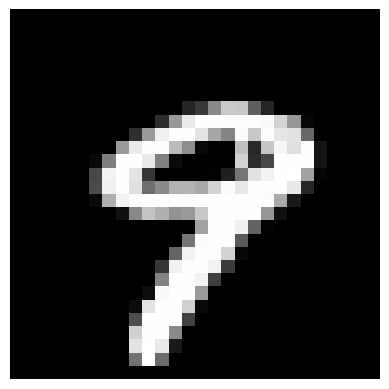

In [42]:
import matplotlib.pyplot as plt

plt.imshow(X_test[9], cmap="gray")
plt.axis("off")
plt.show()